In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
import seaborn as sns

In [3]:
df = pd.read_csv('Mall_customers.csv')
df

,CustomerID,Gender,Age,Annual_Income_(k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual_Income_(k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
numeric_cols2 = ['CustomerID', 'Age', 'Annual_Income_(k$)']
categorical_cols = ['Gender']

In [6]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols), index=df.index)

In [7]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# numeric_scaled = scaler.fit_transform(df[numeric_cols])
# numeric_scaled_df = pd.DataFrame(
#     numeric_scaled,
#     columns=numeric_cols,
#     index=df.index
# )

In [8]:
print(type(numeric_cols2))

<class 'list'>


In [9]:
numeric_df = df[numeric_cols2]

X = pd.concat([numeric_df, encoded_df], axis=1)
X = df[['Annual_Income_(k$)', 'Spending Score (1-100)']]

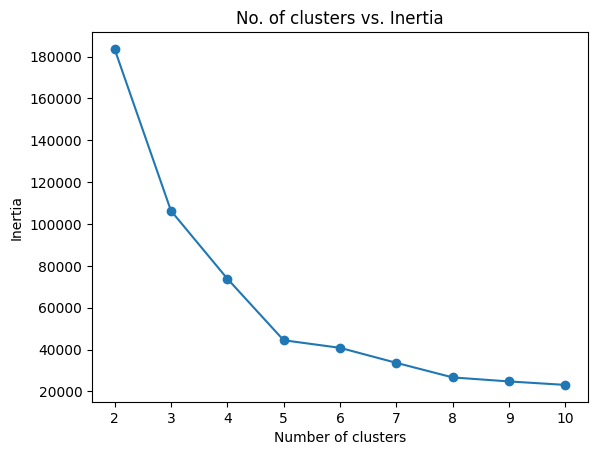

In [10]:
options = range(2,11)
inertias = []

for n_clusters in options:
    model = KMeans(n_clusters=n_clusters, random_state=42)
    model.fit(X)
    inertias.append(model.inertia_)

plt.plot(options, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('No. of clusters vs. Inertia')
plt.show()

In [11]:
model = KMeans(n_clusters=8, random_state=42)
model.fit(X)
model.cluster_centers_

array([[ 55.36486486,  50.40540541],
       [108.18181818,  82.72727273],
       [ 78.89285714,  17.42857143],
       [ 25.72727273,  79.36363636],
       [ 24.58333333,   9.58333333],
       [ 78.03571429,  81.89285714],
       [ 31.53333333,  35.86666667],
       [109.7       ,  22.        ]])

In [12]:
preds = model.fit_predict(X)
preds

array([6, 3, 4, 3, 6, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 6, 3, 6, 3, 6, 3,
       4, 3, 4, 3, 6, 3, 6, 3, 4, 3, 4, 3, 4, 3, 4, 3, 6, 3, 6, 3, 6, 0,
       6, 3, 0, 6, 6, 6, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 2, 5, 2, 5, 2, 5, 2, 5,
       2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5,
       2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5,
       2, 5, 2, 1, 7, 1, 7, 1, 7, 1, 7, 1, 7, 1, 7, 1, 7, 1, 7, 1, 7, 1,
       7, 1], dtype=int32)

In [13]:
X

,Annual_Income_(k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


Text(0, 0.5, 'Spending Score (1-100)')

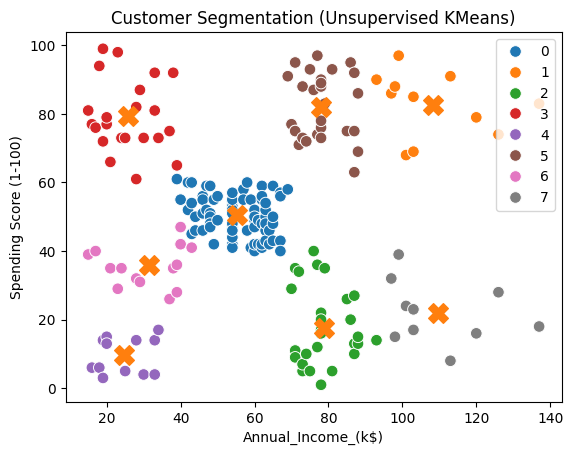

In [16]:
sns.scatterplot(
    data=X,
    x='Annual_Income_(k$)',
    y='Spending Score (1-100)',
    hue=preds,
    palette='tab10',
    s=70
)

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    s=200,
    marker='X'
)
plt.title('Customer Segmentation (Unsupervised KMeans)')
plt.xlabel('Annual_Income_(k$)')
plt.ylabel('Spending Score (1-100)')

In [14]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual_Income_(k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [15]:
?KMeans

Init signature:
KMeans(
    n_clusters=8,
    *,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)
Docstring:     
K-Means clustering.

Read more in the :ref:`User Guide <k_means>`.

Parameters
----------

n_clusters : int, default=8
    The number of clusters to form as well as the number of
    centroids to generate.

    For an example of how to choose an optimal value for `n_clusters` refer to
    :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.

init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
    Method for initialization:

    * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall inertia. This technique speeds up             convergence. The algorithm imple